# Stage 3: DenseNet-121 — V1: Enhanced Stability & Calibration

## 1. Deney Özeti ve Baseline Analizi

### 1.1. Baseline (Önceki Aşama) Sonuçları
Önceki aşamada yapılan 5-Fold Cross-Validation sonuçları şu şekildedir:

| Metrik | Ortalama Skor (Mean ± Std) |
| :--- | :--- |
| **Accuracy** | 0.8716 ± 0.0243 |
| **ACA Recall (Azınlık Sınıf)** | 0.7182 ± 0.0374 |
| **MCA Recall (Çoğunluk Sınıf)** | 0.9096 ± 0.0326 |
| **PCA Recall** | 0.8019 ± 0.0467 |
| **Macro F1-Score** | 0.8070 ± 0.0260 |

### 1.2. Tespit Edilen Sorunlar (Root Cause Analysis)
1.  **Sınıf Dominasyonu (MCA Bias):** Model, veri setinin %70.9'unu oluşturan MCA sınıfında çok yüksek performans gösterirken, ACA sınıfında zorlanmaktadır. Confusion Matrix incelendiğinde ACA örneklerinin önemli bir kısmının MCA olarak yanlış sınıflandırıldığı görülmüştür.
2.  **Aşırı Özgüven (Over-confidence):** Standart `CrossEntropyLoss` kullanımı, modelin tahminlerini 0 veya 1 olmaya zorlamakta, bu da özellikle MCA sınıfında modelin hata payını (uncertainty) görmezden gelmesine yol açmaktadır.
3.  **Model Seçim Kriteri:** Baseline modelinde "Best Model" seçimi `Validation Loss` değerine göre yapılmıştır. Ancak dengesiz veri setlerinde loss değeri, çoğunluk sınıfının başarısı nedeniyle düşük görünebilir ve bu durum azınlık sınıfının (ACA) performansının göz ardı edilmesine neden olabilir.
4.  **Learning Rate Katılığı:** `ReduceLROnPlateau` kullanımı reaktiftir. Model bir yerel minimuma (local minima) takıldığında LR'yi düşürür ancak oradan çıkmak için bir ivme sağlamaz.

### 1.3. V1 Yaklaşımı: Yapılan Değişiklikler
Bu notebook'ta, yukarıdaki sorunları çözmek için şu **incremental (kademeli)** değişiklikler uygulanmıştır:

*   **Label Smoothing (0.1):** Modelin MCA sınıfına karşı aşırı özgüvenini kırmak ve daha genel bir karar sınırı (decision boundary) çizmesini sağlamak için etiketler yumuşatılmıştır.
*   **CosineAnnealingWarmRestarts:** Öğrenme oranını periyodik olarak yükseltip alçaltarak modelin yerel minimumlardan kurtulması ve daha stabil bir yakınsama sağlaması hedeflenmiştir.
*   **Model Saving (Macro F1):** En iyi model artık `Validation Loss` yerine, tüm sınıfların dengeli başarısını temsil eden **Macro F1-Score** metriğine göre kaydedilecektir.

## 2. Setup & Reproducibility

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision
from torchvision import models
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix, 
                             classification_report, roc_auc_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize
from tqdm import tqdm
from collections import Counter

# --- DETERMINISM ---
SEED = 42
def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

set_seed(SEED)
g = torch.Generator()
g.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 3. Sabitler ve Veri Hazırlığı

In [2]:
# --- PATHS & CONFIG ---
STROKE_IMAGES_DIR = '/kaggle/input/stroke-images/flattened_images'
CLASS_NAMES = ['ACA', 'MCA', 'PCA']
NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE = 224
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
NUM_EPOCHS = 100
T_0 = 20 # Scheduler periyodu

def collect_stroke_image_paths(stroke_dir, class_names):
    image_paths, labels = [], []
    for idx, class_name in enumerate(class_names):
        class_dir = Path(stroke_dir) / class_name
        if not class_dir.exists(): continue
        for ext in ['*.png', '*.jpg', '*.jpeg']:
            for img_path in class_dir.glob(ext):
                image_paths.append(str(img_path))
                labels.append(idx)
    return np.array(image_paths), np.array(labels)

all_paths, all_labels = collect_stroke_image_paths(STROKE_IMAGES_DIR, CLASS_NAMES)

# 1. Aşama: %85 Train+Val / %15 Test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    all_paths, all_labels, test_size=0.15, stratify=all_labels, random_state=SEED
)

# 2. Aşama: %85'lik kısımdan %15 (toplamın) Val ayır
# (0.15 / 0.85 ≈ 0.176)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, stratify=y_train_val, random_state=SEED
)

print(f"Eğitim: {len(X_train)} | Doğrulama: {len(X_val)} | Test: {len(X_test)}")

Eğitim: 3227 | Doğrulama: 690 | Test: 692


## 4. Dataset & Augmentation (RAM Caching)

In [3]:
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=0, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

class StrokeDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        self.images = []
        print(f"RAM'e yükleniyor ({len(image_paths)} resim)...")
        for path in tqdm(image_paths):
            img = cv2.imread(path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            self.images.append(img)
            
    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        image, label = self.images[idx], int(self.labels[idx])
        if self.transform:
            image = self.transform(image=image)['image']
        return image, label

# Dataset Nesneleri
train_ds = StrokeDataset(X_train, y_train, transform=train_transform)
val_ds = StrokeDataset(X_val, y_val, transform=val_transform)
test_ds = StrokeDataset(X_test, y_test, transform=val_transform)

# Sampler (Train için)
class_counts = Counter(y_train)
weights = [1.0/class_counts[i] for i in y_train]
sampler = WeightedRandomSampler(weights, len(weights))

# Loaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, worker_init_fn=seed_worker, generator=g)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

RAM'e yükleniyor (3227 resim)...


100%|██████████| 3227/3227 [01:19<00:00, 40.51it/s]


RAM'e yükleniyor (690 resim)...


100%|██████████| 690/690 [00:14<00:00, 47.95it/s]


RAM'e yükleniyor (692 resim)...


100%|██████████| 692/692 [00:15<00:00, 44.00it/s]


## 5. Model, Loss & Scheduler (V1 Spesifik)

In [4]:
def create_model():
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    num_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(num_features, NUM_CLASSES)
    )
    return model

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    return running_loss / total, correct / total

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return running_loss / len(dataloader.dataset), np.array(all_preds), np.array(all_labels), np.array(all_probs)

## 6. Eğitim Döngüsü

In [5]:
model = create_model().to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=T_0, T_mult=1, eta_min=1e-6)

best_f1 = 0.0
history = {'t_loss': [], 't_acc': [], 'v_loss': [], 'v_f1': []}

print(f'\n=== V1 EĞİTİMİ BAŞLIYOR ===')
print(f'{"Epoch":<8} | {"T-Loss":<8} | {"T-Acc":<8} | {"V-Loss":<8} | {"V-F1":<8} | {"LR":<10} | {"Status"}')
print("-" * 75)

# tqdm'i sadece genel ilerlemeyi görmek için bırakıyoruz, çıktıları print ile yapacağız
for epoch in range(1, NUM_EPOCHS + 1):
    # EĞİTİM
    t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    
    # DOĞRULAMA
    v_loss, v_preds, v_labels, _ = validate(model, val_loader, criterion, device)
    
    # Metrik Hesaplama
    v_f1 = f1_score(v_labels, v_preds, average='macro')
    current_lr = optimizer.param_groups[0]['lr']
    
    # Geçmişi Kaydet
    history['t_loss'].append(t_loss)
    history['t_acc'].append(t_acc)
    history['v_loss'].append(v_loss)
    history['v_f1'].append(v_f1)
    
    # Model Kaydetme ve Durum Belirleme
    status = ""
    if v_f1 > best_f1:
        best_f1 = v_f1
        torch.save(model.state_dict(), 'densenet_v1_best.pth')
        status = "★ Best Model Saved"
    
    # SATIR YAZDIRMA (Her epoch için bir satır)
    print(f'{epoch:<8} | {t_loss:<8.4f} | {t_acc:<8.4f} | {v_loss:<8.4f} | {v_f1:<8.4f} | {current_lr:<10.2e} | {status}')
    
    # SCHEDULER STEP (Epoch sonunda)
    scheduler.step()

print("-" * 75)
print(f'Eğitim Tamamlandı. En İyi Macro F1: {best_f1:.4f}')

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 171MB/s]



=== V1 EĞİTİMİ BAŞLIYOR ===
Epoch    | T-Loss   | T-Acc    | V-Loss   | V-F1     | LR         | Status
---------------------------------------------------------------------------
1        | 0.8834   | 0.6185   | 0.8092   | 0.6042   | 1.00e-04   | ★ Best Model Saved
2        | 0.6303   | 0.8100   | 0.6592   | 0.7036   | 9.94e-05   | ★ Best Model Saved
3        | 0.5484   | 0.8618   | 0.6374   | 0.7430   | 9.76e-05   | ★ Best Model Saved
4        | 0.5024   | 0.8884   | 0.5319   | 0.7809   | 9.46e-05   | ★ Best Model Saved
5        | 0.4795   | 0.9058   | 0.5914   | 0.7762   | 9.05e-05   | 
6        | 0.4703   | 0.9111   | 0.5877   | 0.7667   | 8.55e-05   | 
7        | 0.4370   | 0.9250   | 0.5580   | 0.7658   | 7.96e-05   | 
8        | 0.4272   | 0.9365   | 0.5784   | 0.7883   | 7.30e-05   | ★ Best Model Saved
9        | 0.4167   | 0.9377   | 0.5313   | 0.8109   | 6.58e-05   | ★ Best Model Saved
10       | 0.3834   | 0.9600   | 0.5688   | 0.7755   | 5.82e-05   | 
11       | 0.3959   | 

## Akademik değerlendirme & V1 vs Baseline Karşılaştırması


=== V1 TEST SETİ PERFORMANSI ===
Accuracy (Micro F1): 0.8815
Macro F1-Score:      0.8139
Weighted F1-Score:   0.8832
ACA Specificity:      0.9654
MCA Specificity:      0.8458
PCA Specificity:      0.9470

Classification Report:
              precision    recall  f1-score   support

         ACA       0.65      0.73      0.69        56
         MCA       0.93      0.91      0.92       491
         PCA       0.81      0.86      0.83       145

    accuracy                           0.88       692
   macro avg       0.80      0.83      0.81       692
weighted avg       0.89      0.88      0.88       692



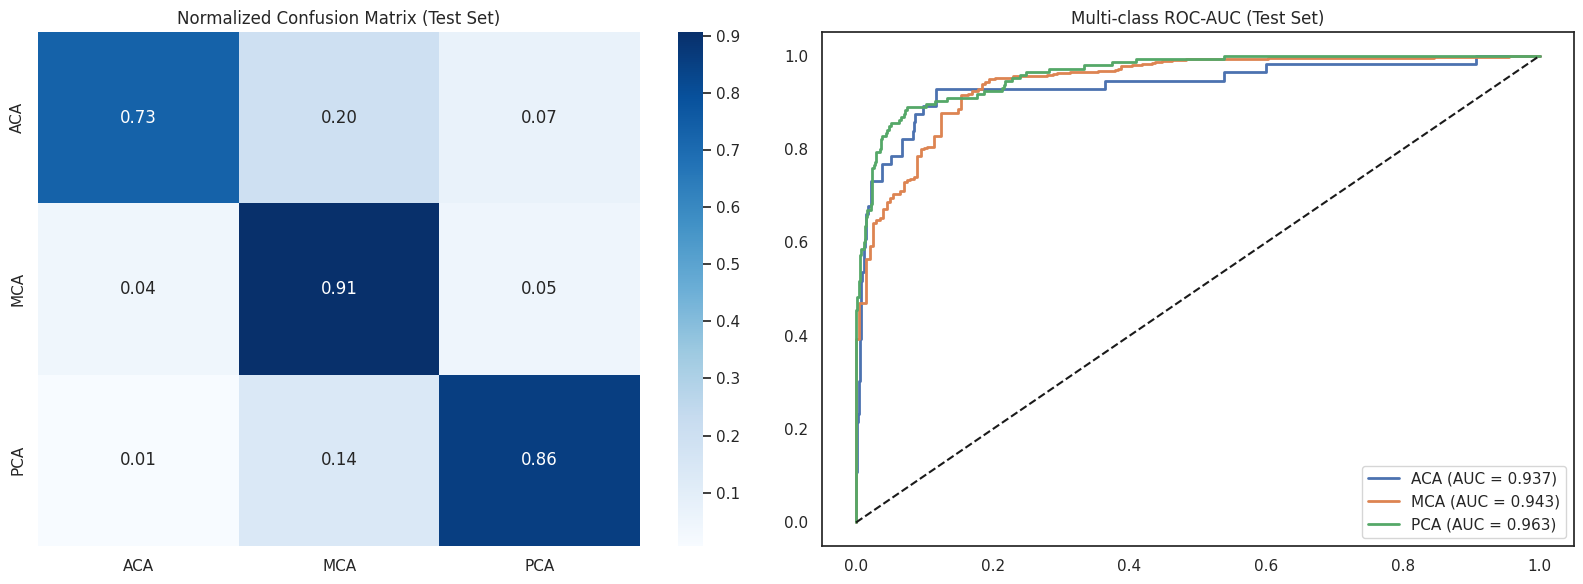

In [6]:
# En iyi modeli yükle
model.load_state_dict(torch.load('densenet_v1_best.pth'))
# Test seti üzerinde değerlendir
_, test_preds, test_labels, test_probs = validate(model, test_loader, criterion, device)

# --- 7.1. Global Metrikler ---
def print_academic_metrics(y_true, y_pred, y_probs):
    print("\n=== V1 TEST SETİ PERFORMANSI ===")
    print(f"Accuracy (Micro F1): {accuracy_score(y_true, y_pred):.4f}")
    print(f"Macro F1-Score:      {f1_score(y_true, y_pred, average='macro'):.4f}")
    print(f"Weighted F1-Score:   {f1_score(y_true, y_pred, average='weighted'):.4f}")
    
    # Specificity hesaplama
    cm = confusion_matrix(y_true, y_pred)
    for i, name in enumerate(CLASS_NAMES):
        tn = np.sum(cm) - (np.sum(cm[i, :]) + np.sum(cm[:, i]) - cm[i, i])
        fp = np.sum(cm[:, i]) - cm[i, i]
        spec = tn / (tn + fp)
        print(f"{name} Specificity:      {spec:.4f}")

print_academic_metrics(test_labels, test_preds, test_probs)
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))

# --- 7.2. Görsel Analiz (CM & ROC) ---
sns.set_theme(style="white")
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax[0], xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax[0].set_title('Normalized Confusion Matrix (Test Set)')

# ROC Curves
y_test_bin = label_binarize(test_labels, classes=[0, 1, 2])
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_probs[:, i])
    ax[1].plot(fpr, tpr, lw=2, label=f'{CLASS_NAMES[i]} (AUC = {auc(fpr, tpr):.3f})')

ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title('Multi-class ROC-AUC (Test Set)')
ax[1].legend()
plt.tight_layout()
plt.show()